# **Replace the standard MLP in each GPT-2 transformer block with a sparse Mixture of Experts (MoE) layer and fine-tune on Alpaca (instruct-reponse dataset)**

# Include auxiliary loss across all experts, and do "soft routing" by summing each of the experts, weighted by the router probability for that expert (instead of top-1 routing)

Import

In [1]:
import torch
import torch.nn as nn
import copy

from transformers import AutoTokenizer, GPT2LMHeadModel, TrainingArguments, Trainer, DataCollatorForSeq2Seq

from datasets import load_dataset

from google.colab import drive
import os

import time
import math
import numpy as np
import scipy.stats as stats
from collections import Counter
from torch.utils.data import DataLoader


Config

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# specify save path
save_directory = "/content/drive/MyDrive/gpt2-moe-alpaca-aux-nam"

Mount Google Drive (to save/load model)

In [3]:
drive.mount('/content/drive')

# create the folder if it does not already exist
os.makedirs(save_directory, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load base GPT2

In [4]:
# instantiate tokenizer
tokenizer = AutoTokenizer.from_pretrained('openai-community/gpt2')

# instantiate base pre-trained GPT2 model
model = GPT2LMHeadModel.from_pretrained('openai-community/gpt2')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [5]:
# print model architecture of base GPT2 model
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [6]:
# look at parameters under the hood in the base GPT2 model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 124,439,808
Trainable Parameters: 124,439,808


In [7]:
# print parameters names and shapes from base GPT2 model
for name, param in model.named_parameters():
    print(f"{name:50} | Shape: {str(param.shape):30} | Trainable: {param.requires_grad}")

transformer.wte.weight                             | Shape: torch.Size([50257, 768])       | Trainable: True
transformer.wpe.weight                             | Shape: torch.Size([1024, 768])        | Trainable: True
transformer.h.0.ln_1.weight                        | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.ln_1.bias                          | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.attn.c_attn.weight                 | Shape: torch.Size([768, 2304])        | Trainable: True
transformer.h.0.attn.c_attn.bias                   | Shape: torch.Size([2304])             | Trainable: True
transformer.h.0.attn.c_proj.weight                 | Shape: torch.Size([768, 768])         | Trainable: True
transformer.h.0.attn.c_proj.bias                   | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.ln_2.weight                        | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.ln_

In [8]:
# # test code for direct parameter modification

# # isolate the specific parameters to change (e.g., first token embedding layer; see list above)
# embedding_weights = model.transformer.wte.weight

# # manually adjust parameters
# # use in-place operations with underscore suffix (e.g., .mul_(), .add_(), .copy_()) to update underlying PyTorch data
# with torch.no_grad(): # disable gradient calculation / computation graph
#     # multiply all weights by a specific scalar factor (e.g., 1.5)
#     embedding_weights.mul_(1.5)

#     # another example, manually set a specific parameter tensor to a custom tensor
#     # new_weights = torch.randn_like(embedding_weights)
#     # embedding_weights.copy_(new_weights)

In [9]:
# set base GPT2 model to evaluation mode
model.eval()

# tokenize input
inputs = tokenizer('Hello, my dog is cute', return_tensors='pt')

# generate token outputs from model
outputs = model.generate(**inputs, max_length=20)

# detokenize output into readable text
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generated_text)


Hello, my dog is cute. I'm not sure if she's a puppy or not. I


In each transformer block of GPT, replace MLP with router network plus 4 experts

In [10]:

# create custom PyTorch module for the GPT2 MoE Layer
# add a router network (selects the expert model)
# and 4 experts
#
# also have routing logging to see which experts are being called

class GPT2MoELayer(nn.Module):
    def __init__(self, original_mlp, num_experts=4, aux_loss_coef=0.05):
        super().__init__()
        self.num_experts = num_experts
        self.aux_loss_coef = aux_loss_coef

        # Extract hidden dimension
        hidden_dim = original_mlp.c_fc.weight.shape[0]

        # Router network and expert clones
        self.router = nn.Linear(hidden_dim, num_experts)
        self.experts = nn.ModuleList([copy.deepcopy(original_mlp) for _ in range(num_experts)])

        # Tracking telemetry (safe for training, defaults to off)
        self.routing_log = []
        self.track_routing = False

        # Save routing probabilities for external loss calculation
        self.saved_router_probs = None

    def forward(self, hidden_states, attention_mask=None):
        orig_shape = hidden_states.shape
        flat_hidden_states = hidden_states.view(-1, orig_shape[-1])

        # Compute routing probabilities
        router_logits = self.router(flat_hidden_states)
        router_probs = torch.softmax(router_logits, dim=-1)

        # Save probabilities so the Trainer can calculate Aux Loss later
        if self.training:
            self.saved_router_probs = router_probs

        # Keep top-1 calculation purely for logging compatibility
        top1_weights, top1_indices = torch.topk(router_probs, k=1, dim=-1)
        flat_indices = top1_indices.squeeze(-1)

        # Log tokens during evaluation
        if self.track_routing:
            self.routing_log.extend(flat_indices.tolist())

        # Execute expert computations (Soft Routing / Additive)
        flat_outputs = torch.zeros_like(flat_hidden_states)
        for expert_idx in range(self.num_experts):
            # Compute output from this expert for all tokens
            expert_outputs = self.experts[expert_idx](flat_hidden_states)
            # Weight the output by the router probability for this expert
            expert_weights = router_probs[:, expert_idx].unsqueeze(-1)
            flat_outputs += expert_outputs * expert_weights

        return flat_outputs.view(orig_shape)


In [11]:
# replace the MLPs in the transformer blocks

# Loop through each transformer layer and inject the MoE block
for i in range(len(model.transformer.h)):
    original_mlp = model.transformer.h[i].mlp
    moe_layer = GPT2MoELayer(original_mlp, num_experts=4)

    # Replace the default MLP layer with your custom MoE router/expert layer
    model.transformer.h[i].mlp = moe_layer

In [12]:
# look at new architecture

# Print the updated architecture of the first block to verify the swap
print(model.transformer.h[0])

# Recalculate parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nNew Total Parameters: {total_params:,}")

GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MoELayer(
    (router): Linear(in_features=768, out_features=4, bias=True)
    (experts): ModuleList(
      (0-3): 4 x GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
)

New Total Parameters: 294,484,272


Fine-tune the new GPT2_MoE model with Alpaca (instruct and response)

In [13]:
# fine-tune the new GPT2_MoE model using Alpaca (instruct and response)

# Load the Alpaca dataset
dataset = load_dataset("tatsu-lab/alpaca")
# Split into train/validation for tracking performance
dataset = dataset["train"].train_test_split(test_size=0.05, seed=42)

README.md:   0%|          | 0.00/7.47k [00:00<?, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…): reconstructing file:   0%|          |  0.00B / 24.2MB            

data/train-00000-of-00001-a09b74b3ef9c3b(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Tokenize Alpaca dataset

In [14]:
# tokenize Alpaca dataset

# Configure padding token
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

def preprocess_alpaca(examples):
    prompts = []
    labels = []

    for i in range(len(examples["instruction"])):
        # Apply standard Alpaca formatting based on whether 'input' is provided
        if examples["input"][i]:
            prompt = (
                f"Below is an instruction that describes a task, paired with an input that provides further context. "
                f"Write a response that appropriately completes the request.\n\n"
                f"### Instruction:\n{examples['instruction'][i]}\n\n"
                f"### Input:\n{examples['input'][i]}\n\n"
                f"### Response:\n"
            )
        else:
            prompt = (
                f"Below is an instruction that describes a task. "
                f"Write a response that appropriately completes the request.\n\n"
                f"### Instruction:\n{examples['instruction'][i]}\n\n"
                f"### Response:\n"
            )

        response = examples["output"][i] + tokenizer.eos_token
        full_text = prompt + response

        # Tokenize prompt and full text separately to isolate lengths
        tokenized_prompt = tokenizer(prompt, truncation=True, max_length=512)["input_ids"]
        tokenized_full = tokenizer(full_text, truncation=True, max_length=512)["input_ids"]

        prompt_len = len(tokenized_prompt)

        # Construct label sequence: mask the prompt with -100, keep response token IDs
        label = [-100] * prompt_len + tokenized_full[prompt_len:]

        prompts.append(full_text)
        labels.append(label)

    # Re-tokenize everything uniformly with padding
    model_inputs = tokenizer(prompts, max_length=512, truncation=True, padding="max_length")

    # Pad the labels dynamically to match max_length
    padded_labels = []
    for l in labels:
        padded_l = l + [-100] * (512 - len(l))
        padded_labels.append(padded_l[:512])

    model_inputs["labels"] = padded_labels
    return model_inputs

# Map tokenization across entire dataset
tokenized_datasets = dataset.map(
    preprocess_alpaca,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/49401 [00:00<?, ? examples/s]

Map:   0%|          | 0/2601 [00:00<?, ? examples/s]

In [15]:
# specify save path
dataset_save_directory = "/content/drive/MyDrive/tokenized_alpaca"

# save tokenized dataset (dataset dictionary) to Google drive
tokenized_datasets.save_to_disk(dataset_save_directory)

Saving the dataset (0/1 shards):   0%|          | 0/49401 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2601 [00:00<?, ? examples/s]

Training

In [16]:
# training

# training parameters
training_args = TrainingArguments(
    output_dir="./gpt2-moe-alpaca",
    per_device_train_batch_size=4,      # Scale based on available VRAM
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,     # Simulates a total batch size of 32
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    learning_rate=5e-5,                # Low learning rate preserves frozen-cloned layers
    weight_decay=0.01,
    warmup_ratio=0.03,                 # Essential for stabilizing new router layers
    logging_steps=10,
    num_train_epochs=1,                # 1 epoch is standard for Alpaca instruct tuning
    fp16=torch.cuda.is_available(),    # Enable mixed-precision if GPU supports it
    report_to="none"
)

# Use seq2seq data collator to cleanly package tensors
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
# # MoETrainer that takes into account auxiliary loss externally
# class MoETrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         outputs = model(**inputs)
#         loss = outputs.loss

#         # Extract the attention mask natively from the Trainer inputs
#         attention_mask = inputs.get("attention_mask")
#         flat_mask = attention_mask.view(-1).bool() if attention_mask is not None else None

#         total_aux_loss = 0.0

#         # Iterate through layers to compute auxiliary loss, filtering out padding tokens
#         for block in model.transformer.h:
#             if hasattr(block.mlp, 'saved_router_probs') and block.mlp.saved_router_probs is not None:
#                 router_probs = block.mlp.saved_router_probs

#                 # Apply mask to keep only real tokens
#                 if flat_mask is not None and flat_mask.any():
#                     real_probs = router_probs[flat_mask]
#                 else:
#                     real_probs = router_probs

#                 num_experts = block.mlp.num_experts
#                 real_indices = torch.argmax(real_probs, dim=-1)

#                 # Calculate load balancing metrics on real tokens
#                 tokens_per_expert = torch.bincount(real_indices, minlength=num_experts).float()
#                 fraction_tokens = tokens_per_expert / real_indices.size(0)
#                 mean_prob = real_probs.mean(dim=0)

#                 # Calculate and add layer aux loss
#                 layer_aux_loss = block.mlp.aux_loss_coef * num_experts * torch.sum(fraction_tokens * mean_prob)
#                 total_aux_loss += layer_aux_loss

#         total_loss = loss + total_aux_loss
#         return (total_loss, outputs) if return_outputs else total_loss


In [18]:
class MoETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs.loss

        # Extract the attention mask natively from the Trainer inputs
        attention_mask = inputs.get("attention_mask")
        flat_mask = attention_mask.view(-1).bool() if attention_mask is not None else None

        total_aux_loss = 0.0

        # Only compute aux loss during training to prevent using stale router_probs
        if model.training:
            # Iterate through layers to compute auxiliary loss, filtering out padding tokens
            for block in model.transformer.h:
                if hasattr(block.mlp, 'saved_router_probs') and block.mlp.saved_router_probs is not None:
                    router_probs = block.mlp.saved_router_probs

                    # Apply mask to keep only real tokens
                    if flat_mask is not None and flat_mask.any():
                        real_probs = router_probs[flat_mask]
                    else:
                        real_probs = router_probs

                    num_experts = block.mlp.num_experts
                    real_indices = torch.argmax(real_probs, dim=-1)

                    # Calculate load balancing metrics on real tokens
                    tokens_per_expert = torch.bincount(real_indices, minlength=num_experts).float()
                    fraction_tokens = tokens_per_expert / real_indices.size(0)
                    mean_prob = real_probs.mean(dim=0)

                    # Calculate and add layer aux loss
                    layer_aux_loss = block.mlp.aux_loss_coef * num_experts * torch.sum(fraction_tokens * mean_prob)
                    total_aux_loss += layer_aux_loss

        total_loss = loss + total_aux_loss
        return (total_loss, outputs) if return_outputs else total_loss

# Instantiate Trainer with the safely patched MoETrainer
trainer = MoETrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

# Set model back to train state and launch
model.train()
trainer.train()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
200,22.535571,2.121875
400,22.190363,2.074629
600,22.216815,2.050673
800,21.835451,2.022953
1000,21.322943,2.010488
1200,21.677437,2.000323
1400,21.013989,1.993286
1544,21.040691,1.991942


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1544, training_loss=21.902229664856907, metrics={'train_runtime': 1785.2869, 'train_samples_per_second': 27.671, 'train_steps_per_second': 0.865, 'total_flos': 3.871401376378061e+16, 'train_loss': 21.902229664856907, 'epoch': 1.0})

Save fine-tuned GPT2-MoE model to mounted Google Drive location

In [19]:
# save model to google drive

# save model and training configuration
trainer.save_model(save_directory)

# save tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Fine-tuned MoE model has been saved to: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned MoE model has been saved to: /content/drive/MyDrive/gpt2-moe-alpaca-aux-nam


## Evaluation

Routing health metrics - coefficient of variation (CV) and routing entropy (H)

In [20]:

# caclulate coefficient of variation (CV) and routing entropy (H)

def evaluate_routing_health(model, dataloader, device, num_experts=4):
    """
    Evaluates batch-level routing balance, Coefficient of Variation (CV),
    and Routing Entropy across a full dataset split to avoid deceptively
    good global averages.
    """
    model.eval()

    # To store per-batch metrics
    layer_cvs = {i: [] for i in range(len(model.transformer.h))}
    layer_entropies = {i: [] for i in range(len(model.transformer.h))}
    layer_global_counts = {i: Counter() for i in range(len(model.transformer.h))}

    with torch.no_grad():
        for batch in dataloader:
            # Enable routing tracking and reset logs PER BATCH
            for layer in model.transformer.h:
                if hasattr(layer.mlp, 'routing_log'):
                    layer.mlp.routing_log = []
                    layer.mlp.track_routing = True

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

            # Compute CV and Entropy for THIS batch, preventing global smoothing
            for layer_idx, layer in enumerate(model.transformer.h):
                log = layer.mlp.routing_log
                if not log:
                    continue

                counts = Counter(log)
                layer_global_counts[layer_idx].update(counts)
                total_tokens = len(log)

                frequencies = np.array([counts.get(e, 0) / total_tokens for e in range(num_experts)])

                # Calculate Batch Coefficient of Variation (CV)
                cv = np.std(frequencies) / (np.mean(frequencies) + 1e-8)
                layer_cvs[layer_idx].append(cv)

                # Calculate Batch Shannon Entropy (bits)
                entropy = stats.entropy(frequencies + 1e-8, base=2)
                layer_entropies[layer_idx].append(entropy)

            # Disable routing tracking
            for layer in model.transformer.h:
                if hasattr(layer.mlp, 'track_routing'):
                    layer.mlp.track_routing = False

    print("==================== BATCH-AVERAGED MOE ROUTING HEALTH ====================")
    print(f"{'Layer':<6} | {'Mean CV (Load Imbalance)':<25} | {'Mean Entropy':<15} | {'Global Dominant Expert'}")
    print("-" * 75)

    final_cv_scores, final_entropy_scores = [], []

    for layer_idx in range(len(model.transformer.h)):
        if not layer_cvs[layer_idx]:
            continue

        mean_cv = np.mean(layer_cvs[layer_idx])
        mean_entropy = np.mean(layer_entropies[layer_idx])

        final_cv_scores.append(mean_cv)
        final_entropy_scores.append(mean_entropy)

        # Identify globally dominant expert just for context
        total_layer_tokens = sum(layer_global_counts[layer_idx].values())
        dominant_expert = max(layer_global_counts[layer_idx], key=layer_global_counts[layer_idx].get)
        dom_pct = (layer_global_counts[layer_idx][dominant_expert] / total_layer_tokens) * 100

        print(f"L{layer_idx:02d}   | {mean_cv:<25.4f} | {mean_entropy:<15.4f} | Expert {dominant_expert} ({dom_pct:.1f}%)")

    print("-" * 75)
    print(f"Overall Mean Imbalance (CV): {np.mean(final_cv_scores):.4f} (Lower is better)")
    print(f"Overall Mean Entropy:        {np.mean(final_entropy_scores):.4f} / {np.log2(num_experts):.4f} max (Higher is better)")
    print("===========================================================================\n")


Model quality metrics - perplexity

In [21]:
def evaluate_quality_and_perplexity(model, eval_dataset, data_collator, batch_size=8):
    """
    Computes validation perplexity and reference-based text generation quality (ROUGE).
    """
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, collate_fn=data_collator)
    model.eval()

    total_loss = 0.0
    total_steps = 0

    with torch.no_grad():
        for batch in eval_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            total_steps += 1

    avg_loss = total_loss / total_steps
    perplexity = math.exp(avg_loss) if avg_loss < 30 else float("inf")

    print(f"Validation Loss:       {avg_loss:.4f}")
    print(f"Validation Perplexity: {perplexity:.4f}")

    return {"val_loss": avg_loss, "perplexity": perplexity}

System efficiency metrics - token throughput

In [22]:
def benchmark_latency_and_memory(model, tokenizer, prompt="Write a essay about artificial intelligence.", gen_length=100):
    """
    Measures generation throughput (tokens/sec), latency (ms/token), and VRAM usage.
    """
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # Warmup pass
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10)

    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.perf_counter()

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=gen_length, do_sample=False)

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    tokens_generated = output.shape[1] - inputs.input_ids.shape[1]
    throughput = tokens_generated / elapsed_time
    latency_per_token = (elapsed_time / tokens_generated) * 1000
    peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    print("==================== SYSTEM PERFORMANCE ====================")
    print(f"Tokens Generated:   {tokens_generated}")
    print(f"Throughput:         {throughput:.2f} tokens/sec")
    print(f"Latency per Token:  {latency_per_token:.2f} ms")
    print(f"Peak VRAM Usage:    {peak_vram_mb:.2f} MB")
    print("============================================================\n")

Evaluation metrics on test dataset

In [23]:
# Create a PyTorch DataLoader from your existing test split
eval_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=8,
    collate_fn=data_collator
)

# 1. Run Routing Health Diagnostics
print("Evaluating Expert Load & Routing Health...")
evaluate_routing_health(model, eval_dataloader, device, num_experts=4)

# 2. Compute Validation Perplexity
print("Evaluating Validation Loss & Perplexity...")
evaluate_quality_and_perplexity(model, tokenized_datasets["test"], data_collator, batch_size=8)

# 3. Benchmark System Inference Latency
print("Benchmarking Inference Speed & Memory...")
benchmark_latency_and_memory(model, tokenizer, prompt="List three healthy snacks.", gen_length=60)

Evaluating Expert Load & Routing Health...
==================== BATCH-AVERAGED MOE ROUTING HEALTH ====================
Layer  | Mean CV (Load Imbalance)  | Mean Entropy    | Global Dominant Expert
---------------------------------------------------------------------------
L00   | 0.8370                    | 1.5240          | Expert 3 (59.8%)
L01   | 1.3682                    | 0.8709          | Expert 2 (84.2%)
L02   | 0.8279                    | 1.4533          | Expert 2 (51.3%)
L03   | 1.0718                    | 1.2568          | Expert 2 (70.3%)
L04   | 1.3548                    | 0.8964          | Expert 1 (83.6%)
L05   | 1.1563                    | 1.1440          | Expert 0 (74.0%)
L06   | 1.3676                    | 0.8732          | Expert 3 (84.2%)
L07   | 1.3460                    | 0.9110          | Expert 0 (83.3%)
L08   | 1.2795                    | 1.0019          | Expert 1 (80.2%)
L09   | 1.3494                    | 0.9048          | Expert 1 (83.4%)
L10   | 1.3589   

Evaluate single-prompt test cases

In [24]:
# evaluation function with routing logging
# for aggregate sequence


def evaluate_phrase_with_routing(instruction, input_context=""):
    if input_context:
        prompt = (
            f"Below is an instruction that describes a task, paired with an input that provides further context. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_context}\n\n"
            f"### Response:\n"
        )
    else:
        prompt = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n"
        )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # Reset routing logging flags across all 12 independent transformer blocks
    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'routing_log'):
            layer.mlp.routing_log = []
            layer.mlp.track_routing = True

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=60,
            do_sample=True,
            top_k=40,
            top_p=0.9,
            temperature=0.6,
            pad_token_id=tokenizer.eos_token_id
        )

    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'track_routing'):
            layer.mlp.track_routing = False

    response_text = tokenizer.decode(output_tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    # --- PRINT OUT VISUALIZATION RESULTS ---
    print(f"\nPROMPT: {instruction}")
    if input_context: print(f"INPUT:  {input_context}")
    print(f"RESPONSE:\n{response_text}\n")

    print("==================== MOE ROUTING MATRIX ====================")
    # The columns treat each layer's experts as structurally independent entities
    print(f"{'Layer':<6} | {'Expert 0':<12} | {'Expert 1':<12} | {'Expert 2':<12} | {'Expert 3':<12}")
    print("-" * 63)

    for layer_idx, layer in enumerate(model.transformer.h):
        if hasattr(layer.mlp, 'routing_log') and layer.mlp.routing_log:
            layer_counts = Counter(layer.mlp.routing_log)
            total_tokens = sum(layer_counts.values())

            # Safely calculate the unique routing percentage per expert per layer
            p0 = f"{layer_counts[0]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"
            p1 = f"{layer_counts[1]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"
            p2 = f"{layer_counts[2]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"
            p3 = f"{layer_counts[3]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"

            print(f"L{layer_idx:02d}   | {p0:<12} | {p1:<12} | {p2:<12} | {p3:<12}")

    print("===============================================================\n")

In [25]:
# a few test cases

# creative / list generation
evaluate_phrase_with_routing("List three healthy snacks.")

# context processing (instruction + input)
evaluate_phrase_with_routing(
    instruction="Correct the grammar in the sentence.",
    input_context="He do not have no money."
)

# close-ended logic
evaluate_phrase_with_routing("Is the sun a planet or a star?")


PROMPT: List three healthy snacks.
RESPONSE:
Three healthy snacks are banana, avocado, and avocado toast.

==================== MOE ROUTING MATRIX ====================
Layer  | Expert 0     | Expert 1     | Expert 2     | Expert 3    
---------------------------------------------------------------
L00   | 27.7%        | 21.3%        | 31.9%        | 19.1%       
L01   | 14.9%        | 27.7%        | 34.0%        | 23.4%       
L02   | 17.0%        | 34.0%        | 19.1%        | 29.8%       
L03   | 31.9%        | 23.4%        | 12.8%        | 31.9%       
L04   | 21.3%        | 25.5%        | 27.7%        | 25.5%       
L05   | 23.4%        | 14.9%        | 27.7%        | 34.0%       
L06   | 23.4%        | 36.2%        | 25.5%        | 14.9%       
L07   | 17.0%        | 25.5%        | 38.3%        | 19.1%       
L08   | 23.4%        | 23.4%        | 23.4%        | 29.8%       
L09   | 23.4%        | 17.0%        | 21.3%        | 38.3%       
L10   | 17.0%        | 17.0%        | 29

In [26]:
evaluate_phrase_with_routing("what is the capital of canada?")


PROMPT: what is the capital of canada?
RESPONSE:
The capital of canada is Santiago de Compostela.

==================== MOE ROUTING MATRIX ====================
Layer  | Expert 0     | Expert 1     | Expert 2     | Expert 3    
---------------------------------------------------------------
L00   | 20.0%        | 24.0%        | 32.0%        | 24.0%       
L01   | 22.0%        | 26.0%        | 28.0%        | 24.0%       
L02   | 20.0%        | 32.0%        | 16.0%        | 32.0%       
L03   | 28.0%        | 30.0%        | 18.0%        | 24.0%       
L04   | 30.0%        | 26.0%        | 24.0%        | 20.0%       
L05   | 28.0%        | 30.0%        | 20.0%        | 22.0%       
L06   | 10.0%        | 24.0%        | 36.0%        | 30.0%       
L07   | 18.0%        | 32.0%        | 20.0%        | 30.0%       
L08   | 24.0%        | 28.0%        | 18.0%        | 30.0%       
L09   | 28.0%        | 30.0%        | 24.0%        | 18.0%       
L10   | 28.0%        | 10.0%        | 34.0%     

In [27]:
# revised function replaces aggregate sequence averages with a token-by-token routing matrix
# displaying the exact expert (E0-E3) assigned to each individual token across all 12 transformer layers
# (L00–L11)

def evaluate_tokens_with_routing(instruction, input_context="", show_max_tokens=1000):
    """
    Generates a response and displays token-by-token MoE expert selections
    across all transformer layers.
    """
    # Construct standard Alpaca prompt format
    if input_context:
        prompt = (
            f"Below is an instruction that describes a task, paired with an input that provides further context. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_context}\n\n"
            f"### Response:\n"
        )
    else:
        prompt = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n"
        )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    prompt_token_len = inputs.input_ids.shape[1]

    # Reset and enable routing tracking across all 12 transformer blocks
    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'routing_log'):
            layer.mlp.routing_log = []
            layer.mlp.track_routing = True

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            top_k=40,
            top_p=0.9,
            temperature=0.6,
            pad_token_id=tokenizer.eos_token_id
        )

    # Turn off telemetry tracking
    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'track_routing'):
            layer.mlp.track_routing = False

    full_sequence_ids = output_tokens[0]
    response_text = tokenizer.decode(full_sequence_ids[prompt_token_len:], skip_special_tokens=True).strip()

    print(f"\nPROMPT: {instruction}")
    if input_context:
        print(f"INPUT:  {input_context}")
    print(f"RESPONSE:\n{response_text}\n")

    # Build Header for Token-by-Token Matrix
    num_layers = len(model.transformer.h)
    layer_headers = " | ".join([f"L{idx:02d}" for idx in range(num_layers)])

    print("=================== TOKEN-BY-TOKEN MOE ROUTING MATRIX ===================")
    print(f"{'Pos':<4} | {'Type':<6} | {'Token':<16} | {layer_headers}")
    print("-" * (30 + len(layer_headers)))

    num_display = min(len(full_sequence_ids), show_max_tokens)

    for pos_idx in range(num_display):
        tid = full_sequence_ids[pos_idx].item()
        token_str = repr(tokenizer.decode([tid]))
        token_type = "Prompt" if pos_idx < prompt_token_len else "Gen"

        # Gather the expert chosen at pos_idx for every layer
        layer_choices = []
        for layer in model.transformer.h:
            if hasattr(layer.mlp, 'routing_log') and len(layer.mlp.routing_log) > pos_idx:
                expert_id = layer.mlp.routing_log[pos_idx]
                layer_choices.append(f"E{expert_id}")
            else:
                layer_choices.append("E?")

        row_routing = " | ".join(layer_choices)
        print(f"{pos_idx:03d}  | {token_type:<6} | {token_str:<16} | {row_routing}")

    if len(full_sequence_ids) > show_max_tokens:
        print(f"... ({len(full_sequence_ids) - show_max_tokens} remaining tokens omitted for display length)")
    print("=========================================================================\n")

In [28]:
# test cases

# creative / list generation
evaluate_tokens_with_routing("List three healthy snacks.")



PROMPT: List three healthy snacks.
RESPONSE:
Three healthy snacks are fruit smoothies, fruits and vegetables, and chocolate chips.

=================== TOKEN-BY-TOKEN MOE ROUTING MATRIX ===================
Pos  | Type   | Token            | L00 | L01 | L02 | L03 | L04 | L05 | L06 | L07 | L08 | L09 | L10 | L11
---------------------------------------------------------------------------------------------------
000  | Prompt | 'Below'          | E1 | E3 | E1 | E0 | E1 | E1 | E2 | E0 | E3 | E1 | E3 | E3
001  | Prompt | ' is'            | E3 | E1 | E3 | E2 | E2 | E3 | E2 | E0 | E2 | E3 | E2 | E1
002  | Prompt | ' an'            | E3 | E1 | E1 | E1 | E2 | E0 | E2 | E1 | E0 | E2 | E1 | E1
003  | Prompt | ' instruction'   | E1 | E2 | E0 | E0 | E0 | E3 | E3 | E3 | E2 | E3 | E2 | E3
004  | Prompt | ' that'          | E2 | E1 | E1 | E3 | E0 | E0 | E1 | E2 | E0 | E3 | E0 | E1
005  | Prompt | ' describes'     | E2 | E2 | E2 | E0 | E1 | E3 | E3 | E3 | E0 | E3 | E2 | E1
006  | Prompt | ' a'          

In [29]:
evaluate_tokens_with_routing("What is another way of saying around twelve?")


PROMPT: What is another way of saying around twelve?
RESPONSE:
Another way of saying around twelve is "three times as many" (12).

=================== TOKEN-BY-TOKEN MOE ROUTING MATRIX ===================
Pos  | Type   | Token            | L00 | L01 | L02 | L03 | L04 | L05 | L06 | L07 | L08 | L09 | L10 | L11
---------------------------------------------------------------------------------------------------
000  | Prompt | 'Below'          | E1 | E3 | E1 | E0 | E1 | E1 | E2 | E0 | E3 | E1 | E3 | E3
001  | Prompt | ' is'            | E3 | E1 | E3 | E2 | E2 | E3 | E2 | E0 | E2 | E3 | E2 | E1
002  | Prompt | ' an'            | E3 | E1 | E1 | E1 | E2 | E0 | E2 | E1 | E0 | E2 | E1 | E1
003  | Prompt | ' instruction'   | E1 | E2 | E0 | E0 | E0 | E3 | E3 | E3 | E2 | E3 | E2 | E3
004  | Prompt | ' that'          | E2 | E1 | E1 | E3 | E0 | E0 | E1 | E2 | E0 | E3 | E0 | E1
005  | Prompt | ' describes'     | E2 | E2 | E2 | E0 | E1 | E3 | E3 | E3 | E0 | E3 | E2 | E1
006  | Prompt | ' a'           

Evaluate using a heatmap to visualize expert usage

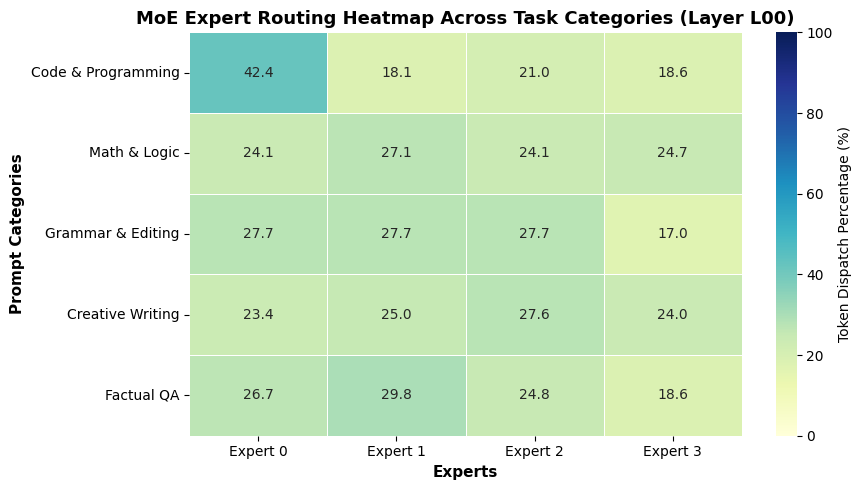

In [30]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# 1. Define distinct prompt categories and sample instructions
prompt_categories = {
    "Code & Programming": [
        "Write a Python function to calculate the Fibonacci sequence.",
        "How do I parse a JSON string in JavaScript?",
        "Fix the bug in this C++ array iteration loop."
    ],
    "Math & Logic": [
        "Solve for x in the equation: 3x + 15 = 45.",
        "If all A are B and all B are C, are all A C?",
        "Calculate the probability of rolling a double six with two dice."
    ],
    "Grammar & Editing": [
        "Correct the grammar in the sentence: He do not have no money.",
        "Rephrase this sentence to sound more professional: I want to quit.",
        "Fix the spelling errors in the word: yesturday."
    ],
    "Creative Writing": [
        "Write a short poem about a quiet rainy afternoon.",
        "List three healthy snacks for a late-night movie.",
        "Draft an opening sentence for a science fiction novel."
    ],
    "Factual QA": [
        "What is the capital of Canada?",
        "Who proposed the theory of general relativity?",
        "Which planet in our solar system is the largest?"
    ]
}

def plot_moe_category_heatmap(model, tokenizer, device, target_layer=0):
    """
    Evaluates prompts across categories, logs expert choices for a target layer,
    and plots a heatmap of expert dispatch percentages.
    """
    model.eval()
    category_routing = {}
    num_experts = model.transformer.h[target_layer].mlp.num_experts

    for category, prompts in prompt_categories.items():
        category_counts = Counter()
        total_tokens = 0

        for prompt in prompts:
            # Format prompt using standard Alpaca structure
            formatted_prompt = (
                f"Below is an instruction that describes a task. "
                f"Write a response that appropriately completes the request.\n\n"
                f"### Instruction:\n{prompt}\n\n"
                f"### Response:\n"
            )

            inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)

            # Reset telemetry for the target layer
            target_mlp = model.transformer.h[target_layer].mlp
            target_mlp.routing_log = []
            target_mlp.track_routing = True

            with torch.no_grad():
                _ = model.generate(
                    **inputs,
                    max_new_tokens=30,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )

            target_mlp.track_routing = False
            log = target_mlp.routing_log

            category_counts.update(log)
            total_tokens += len(log)

        # Calculate average dispatch percentage per expert for this category
        expert_pcts = [
            (category_counts[e] / total_tokens) * 100 if total_tokens > 0 else 0.0
            for e in range(num_experts)
        ]
        category_routing[category] = expert_pcts

    # Construct DataFrame (Rows = Categories, Cols = Experts)
    expert_labels = [f"Expert {e}" for e in range(num_experts)]
    df = pd.DataFrame(category_routing, index=expert_labels).T

    # Render Seaborn Heatmap
    plt.figure(figsize=(9, 5))
    sns.heatmap(
        df,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        cbar_kws={'label': 'Token Dispatch Percentage (%)'},
        linewidths=0.5,
        vmin=0,
        vmax=100
    )
    plt.title(f"MoE Expert Routing Heatmap Across Task Categories (Layer L{target_layer:02d})", fontsize=13, fontweight='bold')
    plt.xlabel("Experts", fontsize=11, fontweight='bold')
    plt.ylabel("Prompt Categories", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df

# Run the visualizer on Layer 0 (or change target_layer to 6 or 11)
df_l0 = plot_moe_category_heatmap(model, tokenizer, device, target_layer=0)

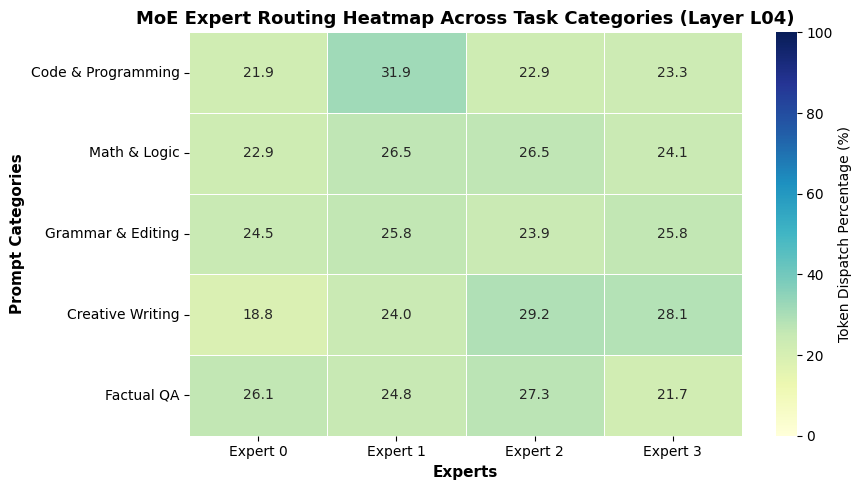

In [31]:
df_l4 = plot_moe_category_heatmap(model, tokenizer, device, target_layer=4)